# 09 - Train in 3D, with autograd holding the gradients

Notebook 08 earned every 2D gradient by hand and checked each one. The
3D pipeline in front of us adds quaternion covariances, the EWA
projection, and a depth sort, and hand-deriving that full chain belongs
in phase D, where each formula has to land inside a CUDA kernel anyway.
What blocks training today is only correctness of gradients, and PyTorch
sells that: rewrite the forward pass in torch, differentiably, and
autograd owns the backward. The price is speed. This notebook pays it,
measures it, and the number it prints is phase D's opening argument.

The setup is self-supervised: the numpy renderer plays the camera.
Twenty-four renders of notebook 05's sphere shell are the ground truth;
a random cloud in the unit ball has to become the sphere by gradient
descent alone. No COLMAP, no capture rig, and any remaining gap is our
optimization's fault, never the data's.

In [1]:
import time
import numpy as np
import matplotlib.pyplot as plt
import torch
import gsplat_edu
from gsplat_edu import Camera, render_gaussians, sphere_shell

torch.manual_seed(9)
DTYPE = torch.float32          # training dtype; every check below runs float64
print("torch", torch.__version__, "| cuda available:", torch.cuda.is_available())

DILATION = 0.3
ALPHA_MIN = 1.0 / 255
ALPHA_MAX = 0.99
Z_NEAR = 0.05
C0 = 0.28209479177387814
SIZE, FX = 128, 150.0          # 512 px * 600 fx from DECISIONS, scaled by 1/4

torch 2.11.0+cu128 | cuda available: True


## Ground truth from the renderer we trust

Three elevation rings, eight azimuths each, radius 3: the reference
camera of record, orbited. One extra camera between the rings never
enters training and judges the result at the end.

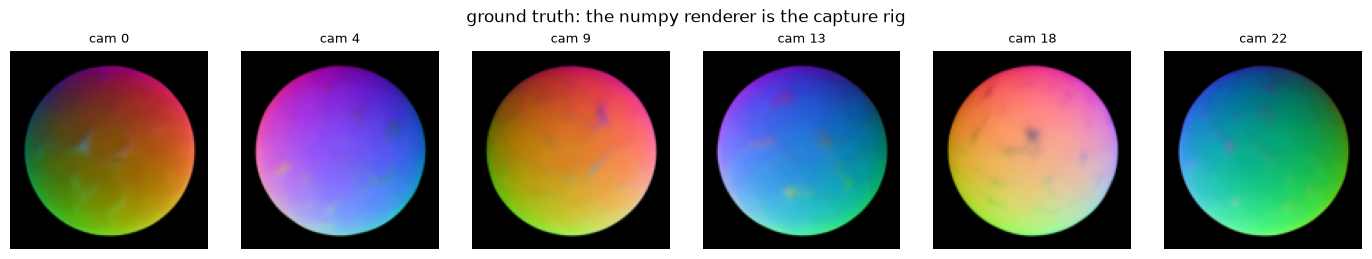

In [2]:
def orbit_camera(az_deg, el, r=3.0):
    a = np.radians(az_deg)
    eye = r * np.array([np.cos(el) * np.sin(a), np.sin(el),
                        -np.cos(el) * np.cos(a)])
    return Camera.looking_at(eye=eye, target=[0, 0, 0],
                             fx=FX, fy=FX, H=SIZE, W=SIZE)

gt_means, gt_covs, gt_colors, gt_opac = sphere_shell()
train_cams = [orbit_camera(az, el)
              for el in (-0.35, 0.0, 0.35) for az in range(0, 360, 45)]
held_out = orbit_camera(202.5, 0.18)

def render_np(cam):
    img, _ = render_gaussians(cam, gt_means, gt_covs, gt_colors, gt_opac)
    return np.clip(img, 0, 1)

gt_images = [torch.tensor(render_np(c), dtype=DTYPE) for c in train_cams]
gt_held = torch.tensor(render_np(held_out), dtype=DTYPE)

fig, axes = plt.subplots(1, 6, figsize=(14, 2.6))
for ax, i in zip(axes, [0, 4, 9, 13, 18, 22]):
    ax.imshow(gt_images[i].numpy()); ax.axis("off")
    ax.set_title(f"cam {i}", fontsize=9)
plt.suptitle("ground truth: the numpy renderer is the capture rig")
plt.tight_layout(); plt.show()

## The forward pass, in torch

Same math as `gsplat_edu.render_gaussians`, restated batched: quaternions
to rotations to covariances, EWA projection as one einsum, dilation,
conic, depth sort, over-compositing. Two deliberate deviations from the
numpy renderer, both named here. First, no per-splat bounding boxes:
torch cannot exploit that locality without a python loop per splat, so
every splat is evaluated against every pixel, in depth-sorted chunks so
memory stays bounded; the bboxes return in phase D, where locality is
the entire subject. Second, no `T_STOP` early exit, for the same reason.
Both skips change only cost, never values, except that the numpy bbox
truncates faint kernel tails a dense evaluation keeps; the parity check
below shows exactly how small that difference is.

In [3]:
def quat_to_R_t(q):
    q = q / q.norm(dim=-1, keepdim=True)
    w, x, y, z = q.unbind(-1)
    return torch.stack([
        torch.stack([1 - 2 * (y * y + z * z), 2 * (x * y - w * z),
                     2 * (x * z + w * y)], -1),
        torch.stack([2 * (x * y + w * z), 1 - 2 * (x * x + z * z),
                     2 * (y * z - w * x)], -1),
        torch.stack([2 * (x * z - w * y), 2 * (y * z + w * x),
                     1 - 2 * (x * x + y * y)], -1)], -2)

def cov3d_t(log_s, quats):
    M = quat_to_R_t(quats) * torch.exp(log_s)[..., None, :]
    return M @ M.mT

def render_t(means, cov3ds, colors, opacities, cam, alpha_min=ALPHA_MIN,
             chunk=512, track_means2d=False):
    """Differentiable render. Returns (img, T_final, means2d, vis_idx)."""
    dev, dt = means.device, means.dtype
    R = torch.tensor(cam.R, dtype=dt, device=dev)
    eye = torch.tensor(cam.eye, dtype=dt, device=dev)
    Pc = (means - eye) @ R.T
    vis = Pc[:, 2] > Z_NEAR
    vis_idx = torch.where(vis)[0]
    Pc, cov3ds = Pc[vis], cov3ds[vis]
    colors, opacities = colors[vis], opacities[vis]

    order = torch.argsort(Pc[:, 2])                  # near to far
    Pc, cov3ds = Pc[order], cov3ds[order]
    colors, opacities = colors[order], opacities[order]
    vis_idx = vis_idx[order]

    x, y, z = Pc.unbind(-1)
    u = cam.fx * x / z + cam.cx
    v = cam.fy * y / z + cam.cy
    means2d = torch.stack([u, v], -1)
    if track_means2d:
        means2d.retain_grad()
    u, v = means2d.unbind(-1)

    zero = torch.zeros_like(z)
    J = torch.stack([
        torch.stack([cam.fx / z, zero, -cam.fx * x / z ** 2], -1),
        torch.stack([zero, cam.fy / z, -cam.fy * y / z ** 2], -1)], -2)
    T_JW = J @ R
    S2 = T_JW @ cov3ds @ T_JW.mT
    a = S2[:, 0, 0] + DILATION
    c = S2[:, 1, 1] + DILATION
    b = S2[:, 0, 1]
    det = a * c - b * b
    A00, A01, A11 = c / det, -b / det, a / det

    ys = torch.arange(cam.H, dtype=dt, device=dev)
    xs = torch.arange(cam.W, dtype=dt, device=dev)
    img = torch.zeros(cam.H, cam.W, 3, dtype=dt, device=dev)
    T_run = torch.ones(cam.H, cam.W, dtype=dt, device=dev)
    for k0 in range(0, len(u), chunk):
        k1 = min(k0 + chunk, len(u))
        dx = xs[None, None, :] - u[k0:k1, None, None]
        dy = ys[None, :, None] - v[k0:k1, None, None]
        power = (-0.5 * (A00[k0:k1, None, None] * dx * dx
                         + A11[k0:k1, None, None] * dy * dy)
                 - A01[k0:k1, None, None] * dx * dy)
        alpha = opacities[k0:k1, None, None] * torch.exp(power)
        alpha = torch.clamp(alpha, max=ALPHA_MAX)
        alpha = torch.where(alpha < alpha_min, torch.zeros_like(alpha), alpha)
        Tc = torch.cumprod(1.0 - alpha, dim=0)
        T_before = torch.cat([T_run[None], T_run * Tc[:-1]], dim=0)
        img = img + torch.einsum("khw,kc->hwc", T_before * alpha,
                                 colors[k0:k1])
        T_run = T_run * Tc[-1]
    return img, T_run, means2d, vis_idx

Before this renderer trains anything, it answers to the two authorities
already in the repo. The batched pieces must match the package functions
bit for bit in float64, and a full render of the toy sphere must match
`gsplat_edu.render_gaussians` up to the one difference just declared:
tails the numpy bbox cuts and the dense evaluation keeps. At the
3-sigma cut a toy-scene splat still carries alpha near 0.009, above
the 1/255 floor, so the difference is small but real; that is why the
check bounds the max loosely and the mean tightly.

In [4]:
rng = np.random.default_rng(9)
q_np = rng.normal(size=(64, 4))
ls_np = rng.normal(size=(64, 3)) * 0.3 - 2.0
assert np.allclose(quat_to_R_t(torch.tensor(q_np)).numpy(),
                   gsplat_edu.quat_to_R_batch(q_np), atol=1e-12)
assert np.allclose(cov3d_t(torch.tensor(ls_np), torch.tensor(q_np)).numpy(),
                   gsplat_edu.build_cov3d_batch(np.exp(ls_np),
                                                gsplat_edu.quat_to_R_batch(q_np)),
                   atol=1e-12)

cam0 = train_cams[8]
img_t, _, _, _ = render_t(torch.tensor(gt_means), torch.tensor(gt_covs),
                          torch.tensor(gt_colors),
                          torch.tensor(gt_opac), cam0)
img_np, _ = render_gaussians(cam0, gt_means, gt_covs, gt_colors, gt_opac)
diff = np.abs(img_t.numpy() - img_np)
print(f"torch vs numpy render: max |diff| {diff.max():.4f}, "
      f"mean {diff.mean():.2e}")
assert diff.max() < 0.05 and diff.mean() < 1e-3

torch vs numpy render: max |diff| 0.0003, mean 7.65e-09


## Autograd, checked the same way the hand gradients were

Trusting autograd does not mean trusting this forward pass; a wrong
formula differentiates perfectly. `torch.autograd.gradcheck` compares
autograd's jacobian against finite differences on a tiny double-precision
scene, raw parameters in, full image out, the exact test notebook 08 ran
on itself. The alpha floor is off for the check, as before: a step
function has no finite difference at its threshold.

In [5]:
def tiny_forward(means, log_s, quats, sh0, o_logit):
    tiny_cam = Camera.looking_at(eye=[0, 0, -3], target=[0, 0, 0],
                                 fx=16, fy=16, H=16, W=16)
    colors = torch.clamp(C0 * sh0 + 0.5, min=0.0)
    img, _, _, _ = render_t(means, cov3d_t(log_s, quats), colors,
                            torch.sigmoid(o_logit), tiny_cam,
                            alpha_min=0.0, chunk=3)
    return img

g = torch.Generator().manual_seed(0)
leaf = lambda *shape: (0.3 * torch.randn(*shape, generator=g,
                                         dtype=torch.float64)).requires_grad_()
inputs = (leaf(4, 3), leaf(4, 3) - 1.0,
          (torch.tensor([[1.0, 0, 0, 0]] * 4, dtype=torch.float64)
           + 0.1 * torch.randn(4, 4, generator=g, dtype=torch.float64)
           ).requires_grad_(),
          leaf(4, 3), leaf(4))
assert torch.autograd.gradcheck(tiny_forward, inputs, eps=1e-6, atol=1e-5)
print("gradcheck: autograd matches finite differences through the full chain")

gradcheck: autograd matches finite differences through the full chain


## Initialization and optimizer

Four hundred splats, uniform in the unit ball, near-gray, low opacity,
nearly isotropic. Parameters and activations follow `docs/DECISIONS.md`;
color is spherical harmonics degree 0 only, so each splat's color is
`clip(C0 * sh0 + 0.5, 0)` and view dependence waits for real data. Loss
is L1, the paper's main term. Adam runs per parameter group. Roadmap
starting rates, with one recorded change: means use 1e-3 rather than
2e-4, because this run lasts 800 iterations, not 30 000, and the cloud
has to physically travel to the shell in that time.

In [6]:
K0, K_CAP = 400, 1600
ITERS = 800
LR = {"means": 1e-3, "log_s": 5e-3, "quats": 1e-3,
      "sh0": 2.5e-3, "o_logit": 5e-2}

def init_params(k, gen):
    d = torch.randn(k, 3, generator=gen, dtype=DTYPE)
    d = d / d.norm(dim=-1, keepdim=True)
    r = torch.rand(k, 1, generator=gen, dtype=DTYPE) ** (1 / 3)
    return {
        "means": (d * r).requires_grad_(),
        "log_s": torch.full((k, 3), np.log(0.09), dtype=DTYPE).requires_grad_(),
        "quats": (torch.tensor([[1.0, 0, 0, 0]] * k, dtype=DTYPE)
                  + 0.01 * torch.randn(k, 4, generator=gen, dtype=DTYPE)
                  ).requires_grad_(),
        "sh0": (0.2 * torch.randn(k, 3, generator=gen, dtype=DTYPE)
                ).requires_grad_(),
        "o_logit": torch.full((k,), -2.2, dtype=DTYPE).requires_grad_(),
    }

class AdamDict:
    """Notebook 08's Adam, dict-keyed, torch tensors, surgery-friendly."""
    def __init__(self, params, lr, b1=0.9, b2=0.999, eps=1e-8):
        self.lr, self.b1, self.b2, self.eps, self.t = lr, b1, b2, eps, 0
        self.m = {k: torch.zeros_like(v) for k, v in params.items()}
        self.v = {k: torch.zeros_like(v) for k, v in params.items()}

    @torch.no_grad()
    def step(self, params):
        self.t += 1
        for k, p in params.items():
            if p.grad is None:
                continue
            self.m[k] = self.b1 * self.m[k] + (1 - self.b1) * p.grad
            self.v[k] = self.b2 * self.v[k] + (1 - self.b2) * p.grad ** 2
            mhat = self.m[k] / (1 - self.b1 ** self.t)
            vhat = self.v[k] / (1 - self.b2 ** self.t)
            p -= self.lr[k] * mhat / (torch.sqrt(vhat) + self.eps)
            p.grad = None

gen = torch.Generator().manual_seed(9)
params = init_params(K0, gen)
opt = AdamDict(params, LR)

def render_current(cam, track=False, alpha_min=ALPHA_MIN):
    colors = torch.clamp(C0 * params["sh0"] + 0.5, min=0.0)
    return render_t(params["means"], cov3d_t(params["log_s"], params["quats"]),
                    colors, torch.sigmoid(params["o_logit"]), cam,
                    alpha_min=alpha_min, track_means2d=track)

with torch.no_grad():
    init_held = render_current(held_out)[0].clone()

## Densify and prune, simplified and admitted

The paper's adaptive density control decides where the model needs more
splats: any splat whose image-space mean keeps receiving large gradients
is failing to explain its region. Small offenders get cloned; large ones
split into two children sampled from the parent's own distribution, with
scales divided by 1.6; splats whose opacity collapses below 0.005 are
pruned. The gradient signal accumulates between densifications as the
mean norm of `d loss / d means2d`, converted to the paper's NDC units
(multiply by W/2) and thresholded at the roadmap's 2e-4.

Deviations from the paper, in full: no opacity reset (our run is 100x
shorter than the 30k iterations that need it); no screen-size prune (at
128 px nothing grows pathological in 800 steps); a hard cap of 1600
splats (the dense torch forward buys memory per splat); the densify
window is iterations 100-600 at interval 100 instead of 500-15000. Adam
moments for surviving splats are carried through the surgery, exactly as
the official trainer does; new splats start with zero moments.

In [7]:
GRAD_TAU = 2e-4
PERCENT_DENSE = 0.01
EXTENT = 3.0                    # camera orbit radius, the paper's proxy

def densify_and_prune(params, opt, accum, count):
    with torch.no_grad():
        opac = torch.sigmoid(params["o_logit"])
        avg = (accum / count.clamp(min=1)) * (SIZE / 2)   # px -> NDC units
        keep = opac >= 0.005
        big = torch.exp(params["log_s"]).max(dim=-1).values \
            > PERCENT_DENSE * EXTENT
        hot = avg > GRAD_TAU
        clone = keep & hot & ~big
        split = keep & hot & big
        keep_after = keep & ~split                       # split parents die

        pieces = {k: [v[keep_after]] for k, v in params.items()}
        mstate = {k: [opt.m[k][keep_after]] for k in params}
        vstate = {k: [opt.v[k][keep_after]] for k in params}

        def add(idx, jitter, shrink):
            n = int(idx.sum())
            if n == 0:
                return 0
            for k, v in params.items():
                new = v[idx].clone()
                if k == "means" and jitter:
                    R = quat_to_R_t(params["quats"][idx])
                    s = torch.exp(params["log_s"][idx])
                    eps = torch.randn(n, 3, generator=gen, dtype=DTYPE)
                    new = new + (R @ (s * eps)[..., None])[..., 0]
                if k == "log_s" and shrink:
                    new = new - np.log(1.6)
                pieces[k].append(new)
                mstate[k].append(torch.zeros_like(new))
                vstate[k].append(torch.zeros_like(new))
            return n

        n_clone = add(clone, jitter=False, shrink=False)
        n_split = int(split.sum())
        add(split, jitter=True, shrink=True)
        add(split, jitter=True, shrink=True)

        new_params = {}
        for k in params:
            cat = torch.cat(pieces[k])[:K_CAP]
            new_params[k] = cat.clone().requires_grad_()
            opt.m[k] = torch.cat(mstate[k])[:K_CAP]
            opt.v[k] = torch.cat(vstate[k])[:K_CAP]
        n_pruned = int((~keep).sum())
        return new_params, n_clone, n_split, n_pruned

## The loop

In [8]:
losses, counts, snaps = [], [], {}
accum = torch.zeros(K0, dtype=DTYPE)
count = torch.zeros(K0, dtype=DTYPE)
order_gen = np.random.default_rng(9)
t_start = time.perf_counter()

for it in range(ITERS):
    cam_i = int(order_gen.integers(len(train_cams)))
    img, _, means2d, vis_idx = render_current(train_cams[cam_i], track=True)
    loss = (img - gt_images[cam_i]).abs().mean()
    loss.backward()
    with torch.no_grad():
        if means2d.grad is not None:
            accum[vis_idx] += means2d.grad.norm(dim=-1)
            count[vis_idx] += 1
    opt.step(params)
    losses.append(float(loss.detach()))
    counts.append(len(params["means"]))
    if it % 100 == 0:
        print(f"iter {it:4d}  L1 {losses[-1]:.4f}  K {counts[-1]}")

    if 100 <= it < 600 and it % 100 == 0:
        params, nc, ns, npr = densify_and_prune(params, opt, accum, count)
        accum = torch.zeros(len(params["means"]), dtype=DTYPE)
        count = torch.zeros_like(accum)
        print(f"           densify: +{nc} cloned, +{2 * ns} split children, "
              f"-{npr} pruned -> K={len(params['means'])}")

    if it == 300:
        with torch.no_grad():
            snaps[it] = render_current(held_out)[0].clone()

wall = time.perf_counter() - t_start
with torch.no_grad():
    final_held = render_current(held_out)[0].clone()
print(f"{ITERS} iters in {wall:.0f} s -> {wall / ITERS * 1e3:.0f} ms/iter "
      f"at {SIZE} px, K~{counts[-1]}")

iter    0  L1 0.2492  K 400


iter  100  L1 0.1346  K 400
           densify: +0 cloned, +568 split children, -0 pruned -> K=684


iter  200  L1 0.0997  K 684
           densify: +0 cloned, +738 split children, -1 pruned -> K=1052


iter  300  L1 0.0502  K 1052
           densify: +0 cloned, +916 split children, -5 pruned -> K=1505


iter  400  L1 0.0283  K 1505
           densify: +8 cloned, +1230 split children, -5 pruned -> K=1600


iter  500  L1 0.0102  K 1600
           densify: +14 cloned, +1374 split children, -5 pruned -> K=1600


iter  600  L1 0.0106  K 1600


iter  700  L1 0.0069  K 1600


800 iters in 171 s -> 214 ms/iter at 128 px, K~1600


held-out L1: init 0.2360 -> final 0.0087


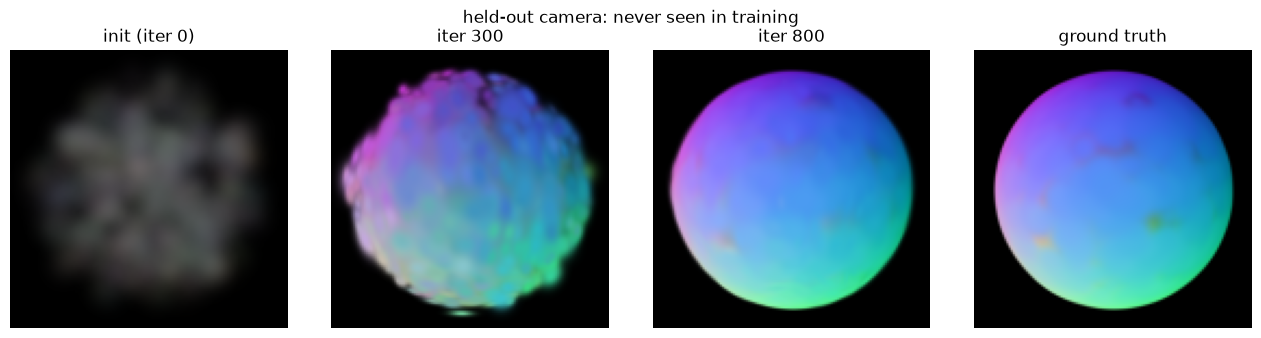

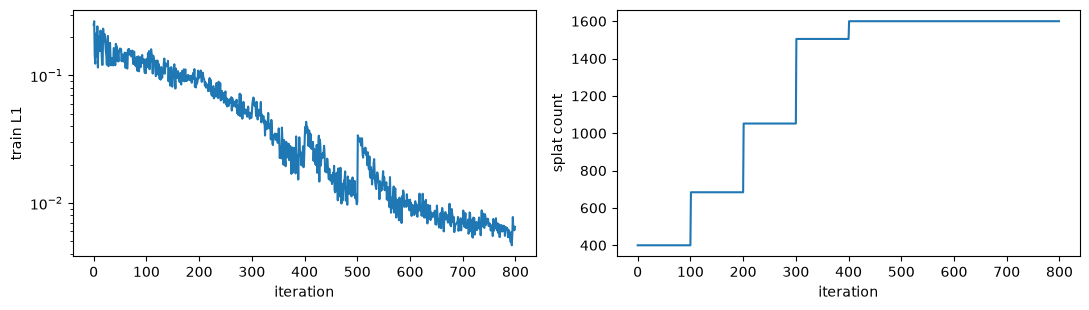

In [9]:
init_l1 = float((init_held - gt_held).abs().mean())
final_l1 = float((final_held - gt_held).abs().mean())
print(f"held-out L1: init {init_l1:.4f} -> final {final_l1:.4f}")
assert final_l1 < 0.3 * init_l1

fig, axes = plt.subplots(1, 4, figsize=(13, 3.4))
for ax, (im, ttl) in zip(axes, [
        (init_held, "init (iter 0)"), (snaps[300], "iter 300"),
        (final_held, f"iter {ITERS}"), (gt_held, "ground truth")]):
    ax.imshow(np.clip(im.numpy(), 0, 1)); ax.axis("off"); ax.set_title(ttl)
plt.suptitle("held-out camera: never seen in training")
plt.tight_layout(); plt.show()

fig, (ax0, ax1) = plt.subplots(1, 2, figsize=(11, 3.2))
ax0.semilogy(losses); ax0.set_xlabel("iteration"); ax0.set_ylabel("train L1")
ax1.plot(counts); ax1.set_xlabel("iteration"); ax1.set_ylabel("splat count")
plt.tight_layout(); plt.show()

The held-out camera never trained, and it sees the sphere anyway: novel
view synthesis, the actual product of this whole method, out of a random
cloud and an L1 loss. The count plot shows density control doing its
job, and the loss curve shows its signature: a brief spike when a batch
of raw split children lands, then a drop below the old floor once they
settle into the regions their parents could not explain.

The same pipeline runs as `python train/train_3d.py` with the budget on
the command line.

## The next live problem

Read the ms-per-iteration line again. This notebook trains a toy at
128 px with a couple thousand splats, on the CPU, in double precision,
and each iteration costs what it costs. The official pipeline runs 30k
iterations on millions of splats at full resolution and finishes in half
an hour, which is three to four orders of magnitude past anything in
this repo. No remaining piece of mathematics closes that gap; notebooks
01-09 have derived everything there is to derive. What remains is phase
D: the same projection, the same recurrence, the same clamps, written as
CUDA kernels, starting with the dumbest one that can possibly work.